# Library importation

In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay,
    classification_report, confusion_matrix
)

# Dataset loading

In [5]:
data = pd.read_csv("loan_dataset.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
print('Rows:', data.shape[0], '| Columns:', data.shape[1])

Rows: 614 | Columns: 13


# Data cleaning

In [11]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [13]:
print(data.describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [15]:
print(data.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [17]:
data.duplicated

<bound method DataFrame.duplicated of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849    

In [19]:
data.drop_duplicates()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# First impressions

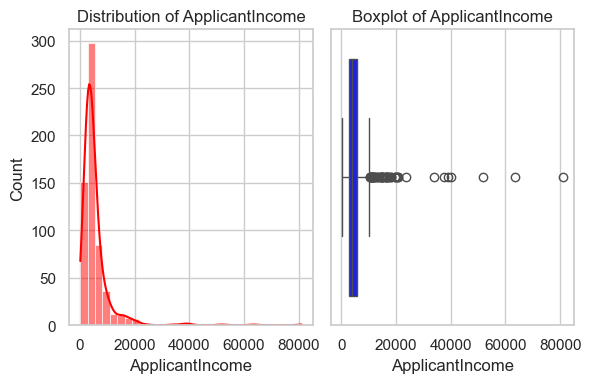

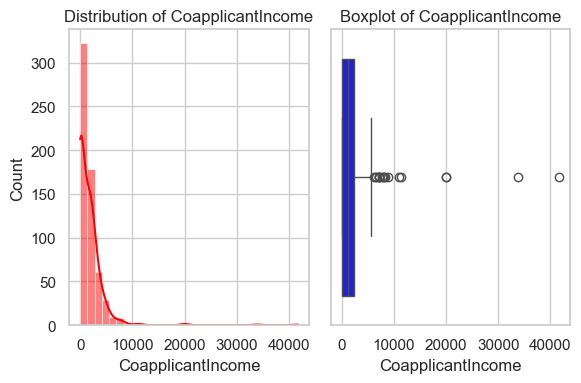

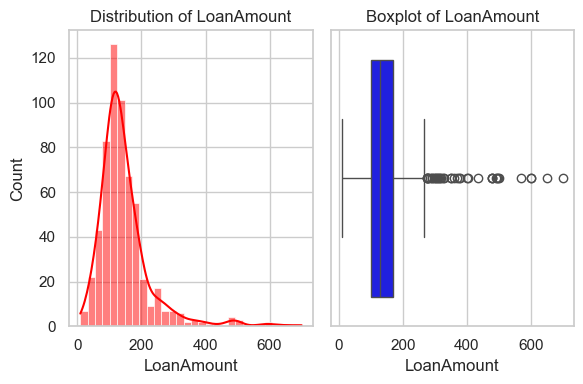

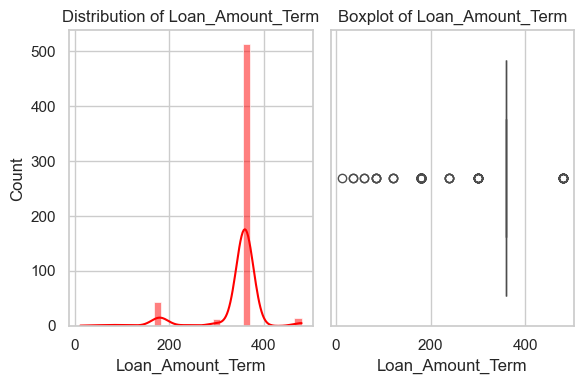

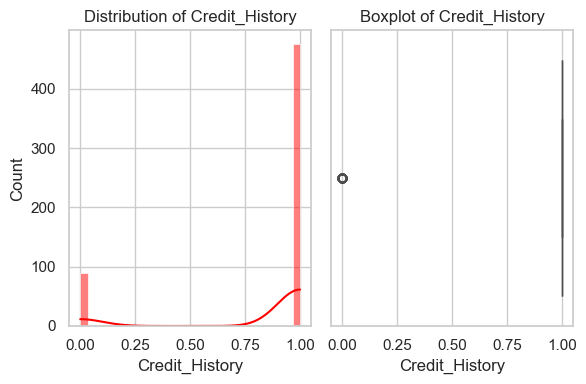

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for column in data.select_dtypes(include=['int','float']).columns:
    plt.figure(figsize=(6, 4))

    
    plt.subplot(1, 2, 1)
    sns.histplot(data[column], kde=True, bins=30, color='red')
    plt.title(f'Distribution of {column}')

    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[column], color='blue')
    plt.title(f'Boxplot of {column}')

    plt.tight_layout()
    plt.show()

These are the distribution and boxplot charts of the numerical variables of our dataset.

As you can see, the application income most of them are concentrated under 10K and on average 5,403 is the value of application income on our dataset.

Coapplicant income, the values are under 5,000 and on average 1,621 is the value of coapplicant income.

LoanAmount it shows how much it has and it seems that most of the loans are around 200.

The loan amount term show us how long it takes to pay their debts, most of them are close to 400 days also it takes 346 days on average those terms.

Credit history it is a binary column that demonstrate if the person have or not a credit (0 = no, 1 = yes) and approximately 85% have it.

After seeing these graphs, my first conclusion is the credit history, income e co applicant income probably will be the most importance features in our model.

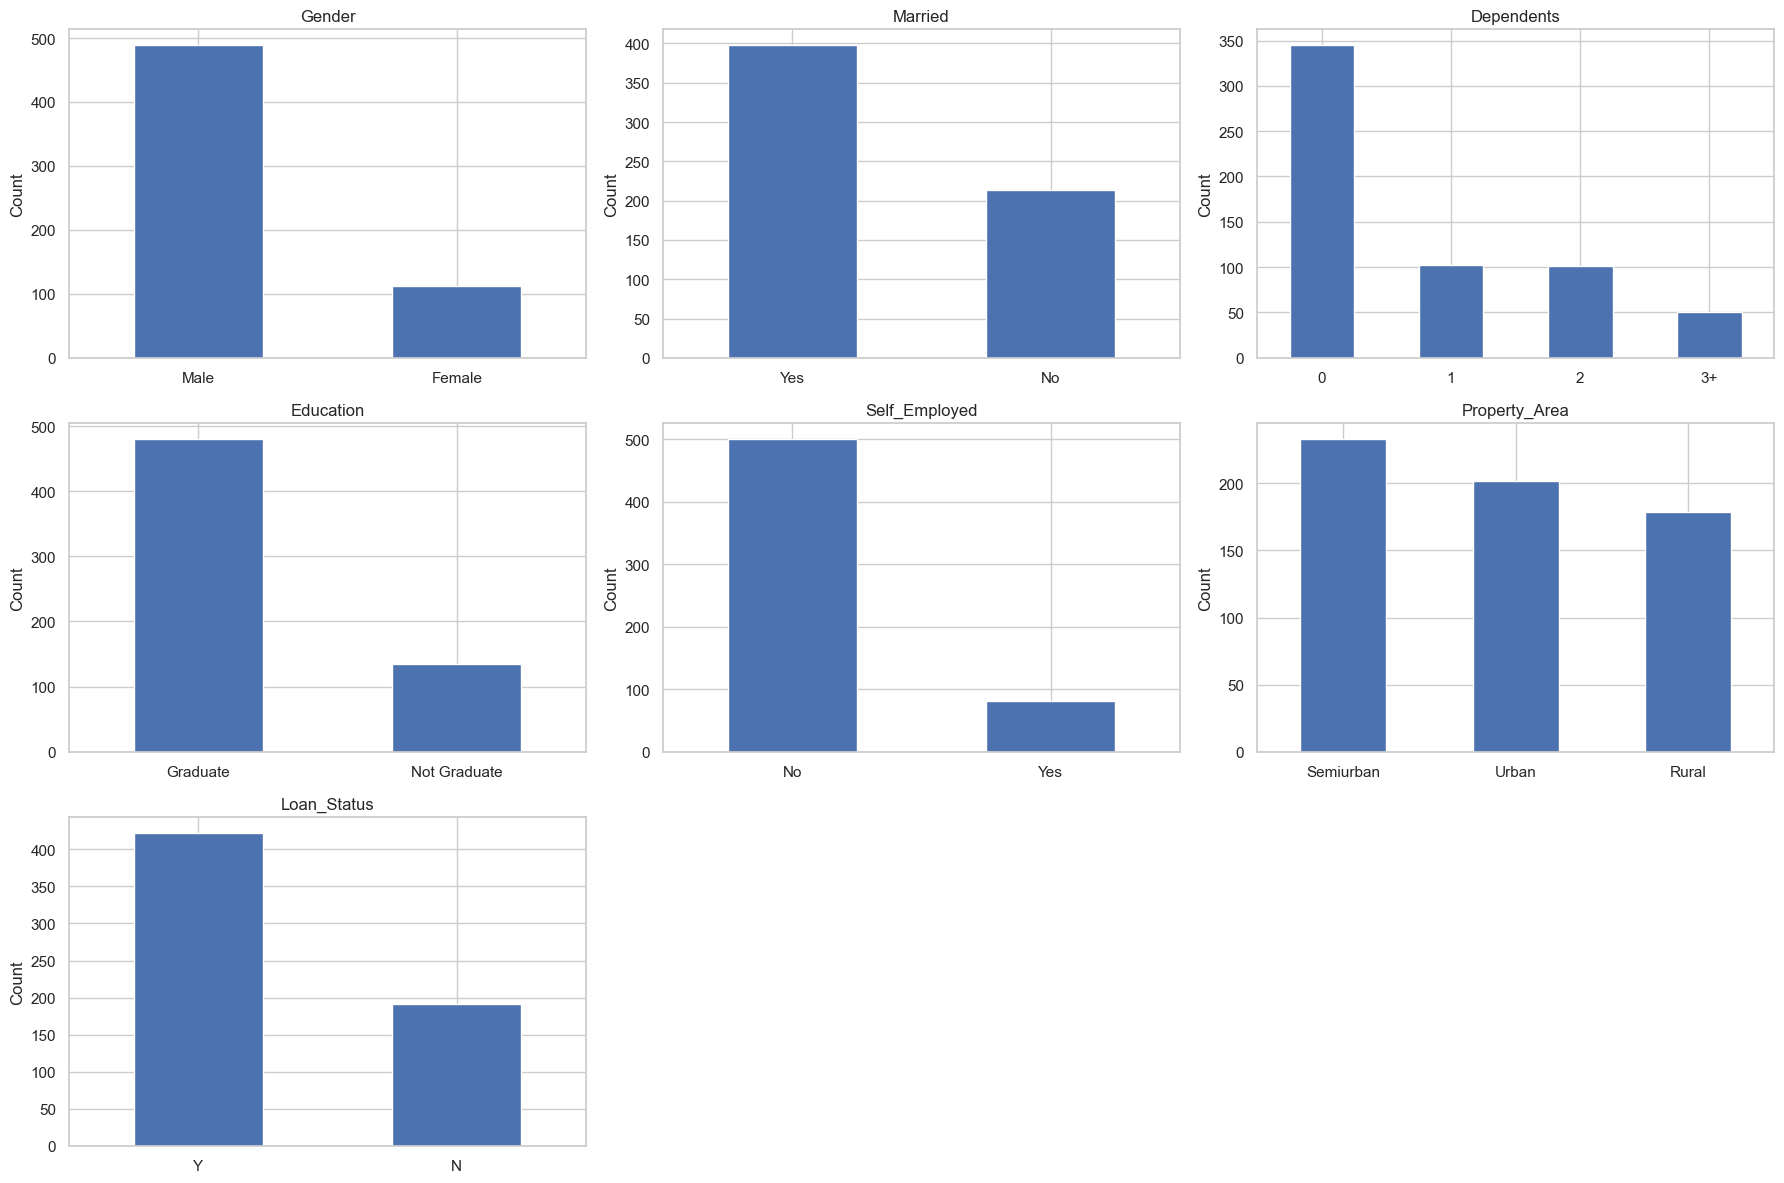

In [25]:
categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()


for i, col in enumerate(categorical_cols):
    data[col].value_counts().plot(
        kind="bar",
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=0)


for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Our dataset contains more male than female also more than 50% are married.

Dependents graph shows if they have dependents or not, approximately 50% does not have.

As you can see, most of them are graduate and they are not self-employed.

In regards to type of property they are living, if we consider semiurban as urban, more than 50% are living in a urban property area.

More than 50% have a loan to be paid.

Now, we already know more about our features, the challenge is with these features is it possible to predict if we should approve or not a loan request?

# Data preparation

In [30]:
numeric_cols= [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

selected_features = numeric_cols + categorical_cols
X = data[selected_features].copy()
y = data["Loan_Status"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop"
)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
preprocess.fit(X, y)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['ApplicantIncome', 'CoapplicantIncome',
                                  'LoanAmount', 'Loan_Amount_Term',
                                  'Credit_History']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Gender', 'Married', 'Dependents',
                                  'Education', 'Self_Employed',
                                  'Property_Area'])])

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


Logistic Regression metrics: {'accuracy': 0.8617886178861789, 'precision': 0.84, 'recall': 0.9882352941176471, 'f1': 0.9081081081081082, 'roc_auc': 0.8523219814241486}


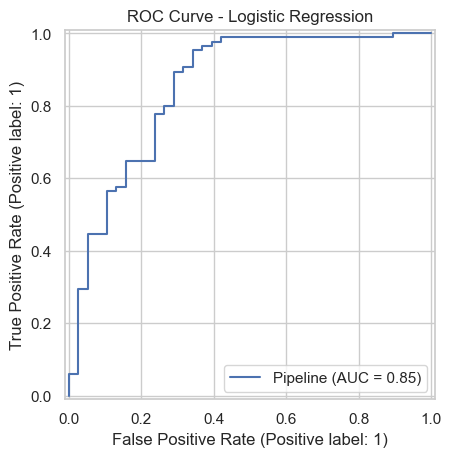

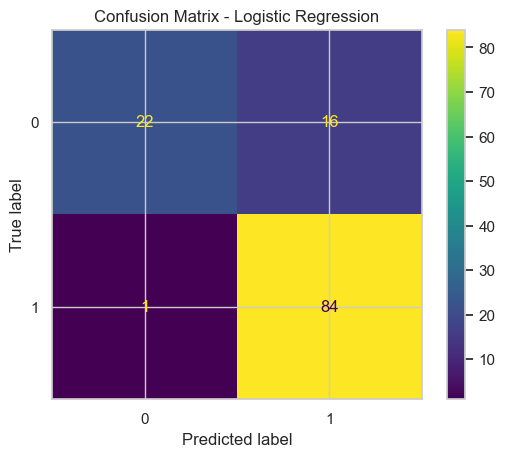

In [38]:
log_reg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, n_jobs=None))
])

log_reg_pipe.fit(X_train, y_train)

y_pred_lr = log_reg_pipe.predict(X_test)
y_proba_lr = log_reg_pipe.predict_proba(X_test)[:, 1]

metrics_lr = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_proba_lr),
}
print("Logistic Regression metrics:", metrics_lr)

RocCurveDisplay.from_estimator(log_reg_pipe, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_lr)).plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The reason we can not see the curve properly is due to the fact that the model made some mistakes to catch approved loans. For our purpose, it is not acceptable, besides our AUC is 0.85 which is a good approach and other results as accuracy 0.86, precision 0.84, recall: 0.98, and f1: 0.90; Low True Positive Rate when False Positive Rate is small, it means poor decision boundary for business use.

Random Forest (untuned) metrics: {'accuracy': 0.8211382113821138, 'precision': 0.8461538461538461, 'recall': 0.9058823529411765, 'f1': 0.875, 'roc_auc': 0.7860681114551084}


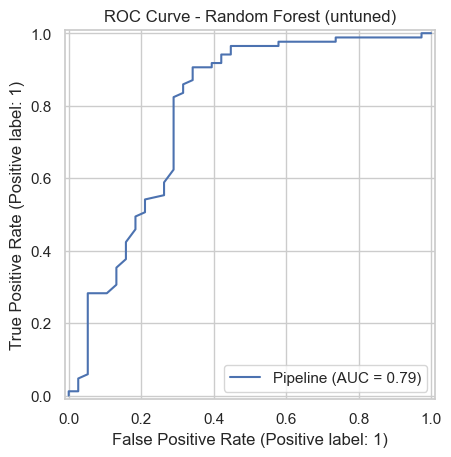

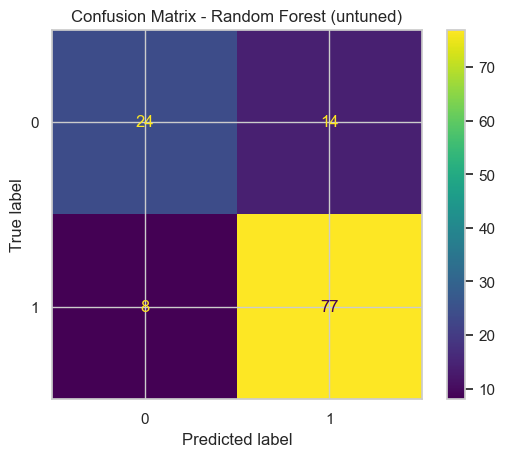

In [41]:
rf_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_base.fit(X_train, y_train)
y_pred_rf0 = rf_base.predict(X_test)
y_proba_rf0 = rf_base.predict_proba(X_test)[:, 1]

metrics_rf0 = {
    "accuracy": accuracy_score(y_test, y_pred_rf0),
    "precision": precision_score(y_test, y_pred_rf0),
    "recall": recall_score(y_test, y_pred_rf0),
    "f1": f1_score(y_test, y_pred_rf0),
    "roc_auc": roc_auc_score(y_test, y_proba_rf0),
}
print("Random Forest (untuned) metrics:", metrics_rf0)

RocCurveDisplay.from_estimator(rf_base, X_test, y_test)
plt.title("ROC Curve - Random Forest (untuned)")
plt.show()

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_rf0)).plot()
plt.title("Confusion Matrix - Random Forest (untuned)")
plt.show()

Our AUC is 0.79, accuracy 0.82, precision 0.84, recall 0.90 and f1 0.87, when the sharp jumps show instability also it suggests that we have a small dataset and the random forest model is not learning properly but it is common on loan datasets.

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Random Forest (tuned) metrics: {'accuracy': 0.8211382113821138, 'precision': 0.8315789473684211, 'recall': 0.9294117647058824, 'f1': 0.8777777777777778, 'roc_auc': 0.790092879256966}


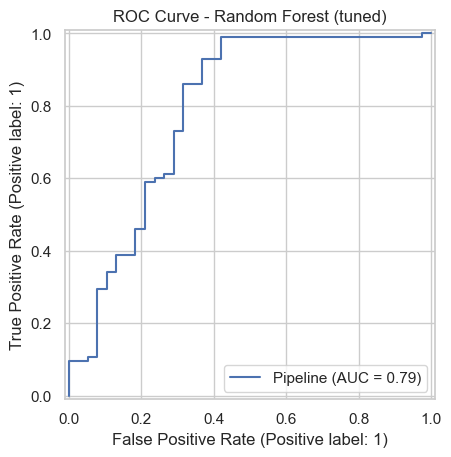

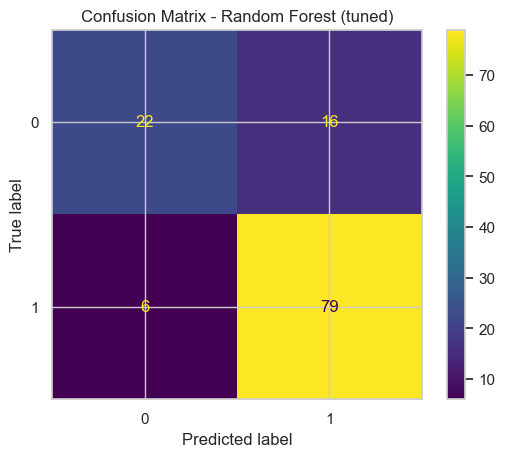

In [44]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
}

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
best_rf = grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
}
print("Random Forest (tuned) metrics:", metrics_rf)

RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("ROC Curve - Random Forest (tuned)")
plt.show()

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_rf)).plot()
plt.title("Confusion Matrix - Random Forest (tuned)")
plt.show()

Our AUC is 0.79, accuracy 0.82, precision 0.83, recall 0.92 and f1 0.88, those data shows that we are approving more creditworthy applicants, it means our model is too generous with the application even risks are being taken loans. Basically, almost everyone is being accepted.

In [47]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


Fitting 5 folds for each of 192 candidates, totalling 960 fits


C:\Users\vitor\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[LightGBM] [Info] Number of positive: 337, number of negative: 154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': -1, 'model__min_child_samples': 20, 'model__n_estimators': 500, 'model__num_leaves': 15, 'model__subsample': 0.8}
LightGBM (tuned) metrics: {'accuracy': 0.8048780487804879, 'precision': 0.8674698795180723, 'recall': 0.8470588235294118, 'f1': 0.8571428571428571, 'roc_auc': 0.7987616099071209}


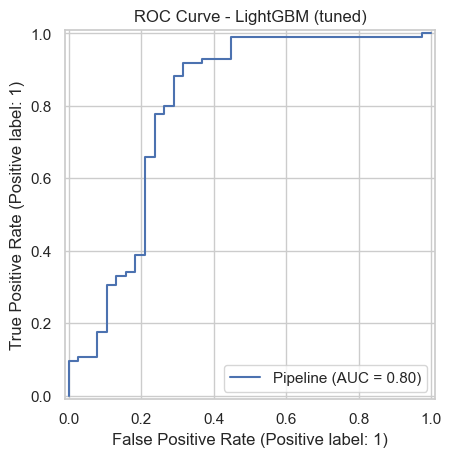

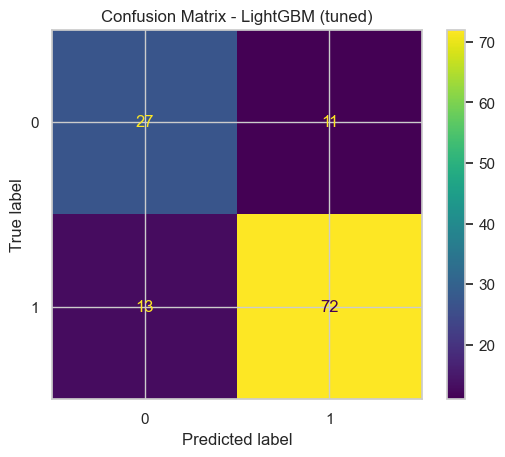

In [49]:
from lightgbm import LGBMClassifier

param_grid_lgbm = {
    "model__n_estimators": [300, 500],
    "model__learning_rate": [0.03, 0.05],
    "model__max_depth": [-1, 4, 6],
    "model__num_leaves": [15, 31],
    "model__min_child_samples": [20, 40],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

lgbm_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

grid_lgbm = GridSearchCV(
    lgbm_pipe,
    param_grid=param_grid_lgbm,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lgbm.fit(X_train, y_train)
print("Best params:", grid_lgbm.best_params_)
best_lgbm = grid_lgbm.best_estimator_

y_pred_lgbm = best_lgbm.predict(X_test)
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]


metrics_lgbm = {
    "accuracy": accuracy_score(y_test, y_pred_lgbm),
    "precision": precision_score(y_test, y_pred_lgbm),
    "recall": recall_score(y_test, y_pred_lgbm),
    "f1": f1_score(y_test, y_pred_lgbm),
    "roc_auc": roc_auc_score(y_test, y_proba_lgbm),
}

print("LightGBM (tuned) metrics:", metrics_lgbm)

RocCurveDisplay.from_estimator(best_lgbm, X_test, y_test)
plt.title("ROC Curve - LightGBM (tuned)")
plt.show()

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_lgbm)
).plot()
plt.title("Confusion Matrix - LightGBM (tuned)")
plt.show()


Our AUC is 0.80, accuracy 0.80, precision 0.87, recall 0.85 and f1 0.86, the precision had increased considerably when compared to others models, it means that fewer risky loans approved, the ROC AUC it has a better ranking overall, the recall decreased given good applicants rejected and F1 lower level, resulting in worse balance overall.

# Model Interpretation and Discussion

Model Comparison:


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.862,0.840,0.988,0.908,0.852
Random Forest (untuned),0.821,0.846,0.906,0.875,0.786
Random Forest (tuned),0.821,0.832,0.929,0.878,0.790
LightGBM (tuned),0.805,0.867,0.847,0.857,0.799


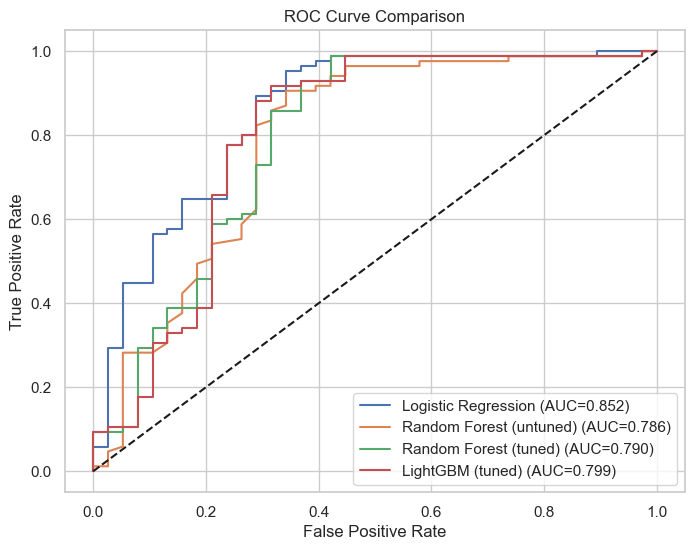

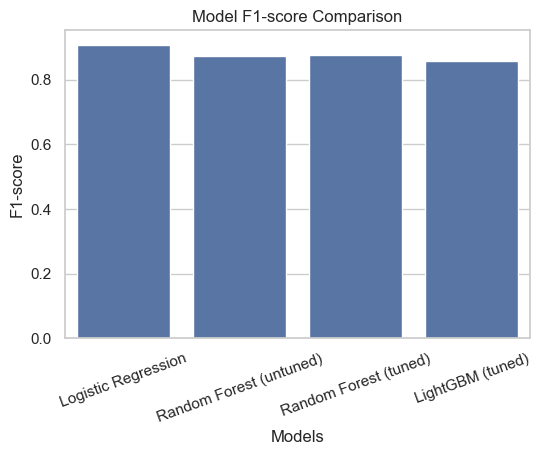


Best Tuned Random Forest Parameters:
model__n_estimators: 200
model__max_depth: None
model__min_samples_split: 5


In [55]:
from sklearn.metrics import roc_curve


if "preprocessor" in locals():
    preprocess = preprocessor
elif "preprocess" in locals():
    preprocess = preprocess
else:
    raise NameError("Neither 'preprocessor' nor 'preprocess' found. Define your preprocessing pipeline first.")

def model_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
    }

log_reg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, n_jobs=-1))
])

rf_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


rf_tuned = best_rf  

lgbm_tuned = best_lgbm

from lightgbm import LGBMClassifier

lgbm_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


log_reg_pipe.fit(X_train, y_train)
rf_base.fit(X_train, y_train)


y_pred_lr = log_reg_pipe.predict(X_test)
y_proba_lr = log_reg_pipe.predict_proba(X_test)[:, 1]

y_pred_rf_untuned = rf_base.predict(X_test)
y_proba_rf_untuned = rf_base.predict_proba(X_test)[:, 1]

y_pred_rf_tuned = rf_tuned.predict(X_test)
y_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

y_pred_lgbm = lgbm_tuned.predict(X_test)
y_proba_lgbm = lgbm_tuned.predict_proba(X_test)[:, 1]



results = pd.DataFrame({
    "Logistic Regression": model_metrics(y_test, y_pred_lr, y_proba_lr),
    "Random Forest (untuned)": model_metrics(y_test, y_pred_rf_untuned, y_proba_rf_untuned),
    "Random Forest (tuned)": model_metrics(y_test, y_pred_rf_tuned, y_proba_rf_tuned),
    "LightGBM (tuned)": model_metrics(y_test, y_pred_lgbm, y_proba_lgbm),
}).T.round(3)

print("Model Comparison:")
display(results)


plt.figure(figsize=(8,6))
for label, y_proba in {
    "Logistic Regression": y_proba_lr,
    "Random Forest (untuned)": y_proba_rf_untuned,
    "Random Forest (tuned)": y_proba_rf_tuned,
    "LightGBM (tuned)": y_proba_lgbm,
}.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()



plt.figure(figsize=(6,4))
sns.barplot(x=results.index, y=results["F1"])
plt.title("Model F1-score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.show()


print("\nBest Tuned Random Forest Parameters:")
for p in ["model__n_estimators", "model__max_depth", "model__min_samples_split"]:
    print(f"{p}: {rf_tuned.get_params().get(p)}")


Logistic regression have a strong linear signal, very few informative interactions, high class overlap and limited dataset size, it means that simple, well-regularized models outperform complex ones, it is a sign of good modelling, not failure.
Despite testing ensemble methods such as Random Forest and LightGBM, Logistic Regression achieved the best overall performance, suggesting that the relationship between applicant features and loan approval is largely linear. Ensemble models improved precision but did not significantly improve overall separability.

# Most importance features

In [59]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("✅ Preprocessing pipeline created successfully.")


Numeric columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
✅ Preprocessing pipeline created successfully.


In [61]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns


cat_transformer = best_rf.named_steps["preprocess"].named_transformers_["cat"]


if hasattr(cat_transformer, "named_steps"):
    ohe = cat_transformer.named_steps["encoder"]
else:
    ohe = cat_transformer

cat_feature_names = ohe.get_feature_names_out(categorical_cols)
num_feature_names = numeric_cols.to_numpy()

all_feature_names = np.concatenate(
    [num_feature_names, cat_feature_names]
)

rf_model = best_rf.named_steps["model"]
importances = rf_model.feature_importances_


feat_imp = (
    pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)



feat_imp.head(15)


,feature,importance
4,Credit_History,0.303571
0,ApplicantIncome,0.166236
2,LoanAmount,0.164261
1,CoapplicantIncome,0.102177
3,Loan_Amount_Term,0.031424
18,Property_Area_Semiurban,0.027142
17,Property_Area_Rural,0.022139
9,Dependents_0,0.019908
10,Dependents_1,0.017894
13,Education_Graduate,0.016401


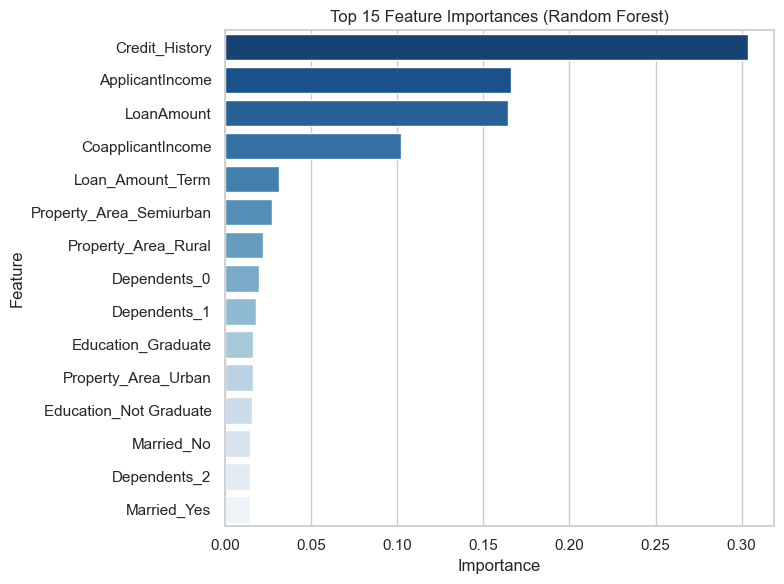

In [63]:
plt.figure(figsize=(8,6))
sns.barplot(
    x="importance",
    y="feature",
    data=feat_imp.head(15),
    hue="feature",           
    palette="Blues_r",
    legend=False             
)

plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Top 3 features (Credit_History, ApplicantIncome and LoanAmount) it has 63.3% of importance to run the models; top 5 features (Credit_History, ApplicantIncome, LoanAmount, CoapplicantIncome and Loan_Amount_Term) contribute to 76.6% of all features importance to develop the model. Feature importance analysis highlights credit history and income-related variables as the most influential factors in loan approval decisions. The model relies primarily on credit history and income-related variables, while demographic attributes play a minor role. This suggests that loan approval decisions are largely driven by financial risk factors rather than personal characteristics.

# SHAP

In [67]:
import shap
shap.initjs()

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred = rf_pipe.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.55      0.67        38
           1       0.83      0.95      0.89        85

    accuracy                           0.83       123
   macro avg       0.83      0.75      0.78       123
weighted avg       0.83      0.83      0.82       123



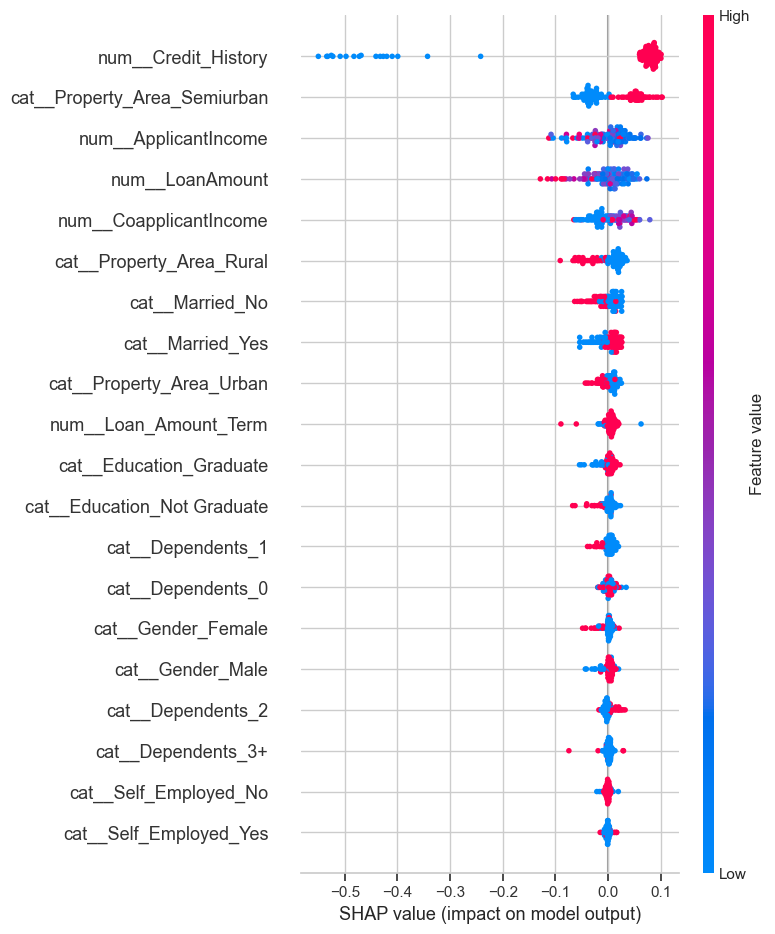

In [71]:
import shap
import numpy as np
import pandas as pd

preprocess_fitted = rf_pipe.named_steps["preprocess"]
rf_model = rf_pipe.named_steps["model"]
X_test_transformed = preprocess_fitted.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

all_feature_names = preprocess_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_transformed, check_additivity=False)

if len(shap_values.shape) == 3:
    sv_to_plot = shap_values[:, :, 1]
else:
    sv_to_plot = shap_values

shap.summary_plot(
    sv_to_plot, 
    X_test_transformed, 
    feature_names=all_feature_names
)

The summary plot shows how each feature contributes to the results. Positive SHAP values are towards the right; Negative SHAP values are towards the left; Positive SHAP values pushes the model towards higher prediction e.g predicting loan, default, failure; Negative SHAP values pushes the model towards a lower probability baseline e.g no loan, no failure etc; Red colour it means high feature value; Blue colour it means low feature value; The features are ordered by importance (global interpretation); Each dot shows how a particular feature affected one prediction (local interpretation); If red is on the right it means high feature value increases prediction; If red is on the left it means high feature value decreases prediction.

In [74]:
print(all_feature_names)

['num__ApplicantIncome' 'num__CoapplicantIncome' 'num__LoanAmount'
 'num__Loan_Amount_Term' 'num__Credit_History' 'cat__Gender_Female'
 'cat__Gender_Male' 'cat__Married_No' 'cat__Married_Yes'
 'cat__Dependents_0' 'cat__Dependents_1' 'cat__Dependents_2'
 'cat__Dependents_3+' 'cat__Education_Graduate'
 'cat__Education_Not Graduate' 'cat__Self_Employed_No'
 'cat__Self_Employed_Yes' 'cat__Property_Area_Rural'
 'cat__Property_Area_Semiurban' 'cat__Property_Area_Urban']


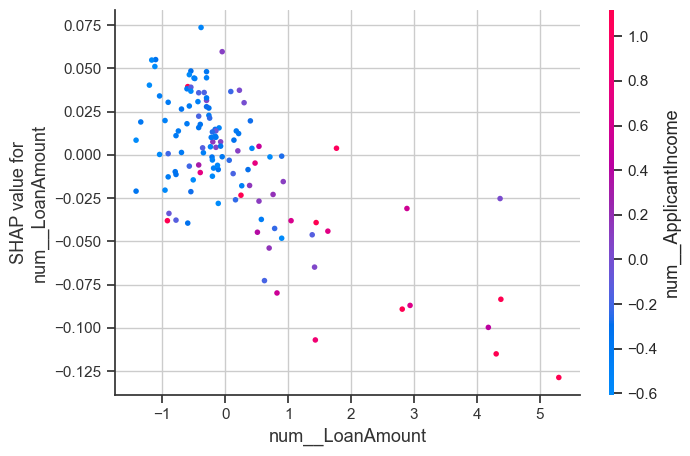

In [78]:
import shap
import numpy as np
import matplotlib.pyplot as plt

preprocess_fitted = rf_pipe.named_steps["preprocess"]
rf_model = rf_pipe.named_steps["model"]
X_test_transformed = preprocess_fitted.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_display_array = np.array(X_test_transformed)

all_feature_names = preprocess_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_transformed, check_additivity=False)

sv_array = shap_values.values[:, :, 1]

feature_name_to_plot = "num__LoanAmount"
feature_index_for_plot = list(all_feature_names).index(feature_name_to_plot)

shap.dependence_plot(
    feature_index_for_plot, 
    sv_array, 
    X_display_array, 
    feature_names=all_feature_names,
    show=False
)
plt.show()


A dependence plot is a scatter plot that shows how model's predictions are affected by a specific feature.

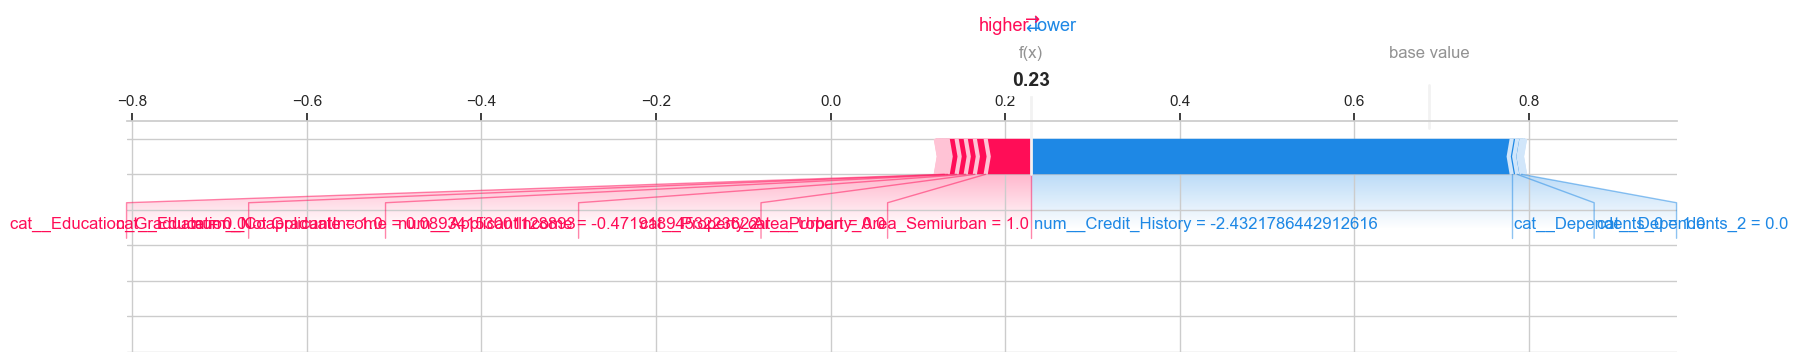

In [87]:
feature_names = all_feature_names

classes = rf_model.classes_
if 1 in classes:
    pos_idx = list(classes).index(1)
elif "Y" in classes:
    pos_idx = list(classes).index("Y")
else:
    pos_idx = 1


if hasattr(shap_values, "values"):
    sv_for_plot = shap_values.values[i, :, pos_idx]
    base_value = shap_values.base_values[i, pos_idx]
else:
    sv_for_plot = shap_values[pos_idx][i]
    base_value = (
        explainer.expected_value[pos_idx]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )

shap.plots.force(
    base_value,
    sv_for_plot,
    X_test_transformed[i],
    feature_names=feature_names,
    matplotlib=True
)

Although the applicant has a graduate education and resides in a semiurban area, the absence of credit history significantly reduces the likelihood of loan approval. Credit history is the most influential factor in the model, outweighing positive socio-economic indicators.

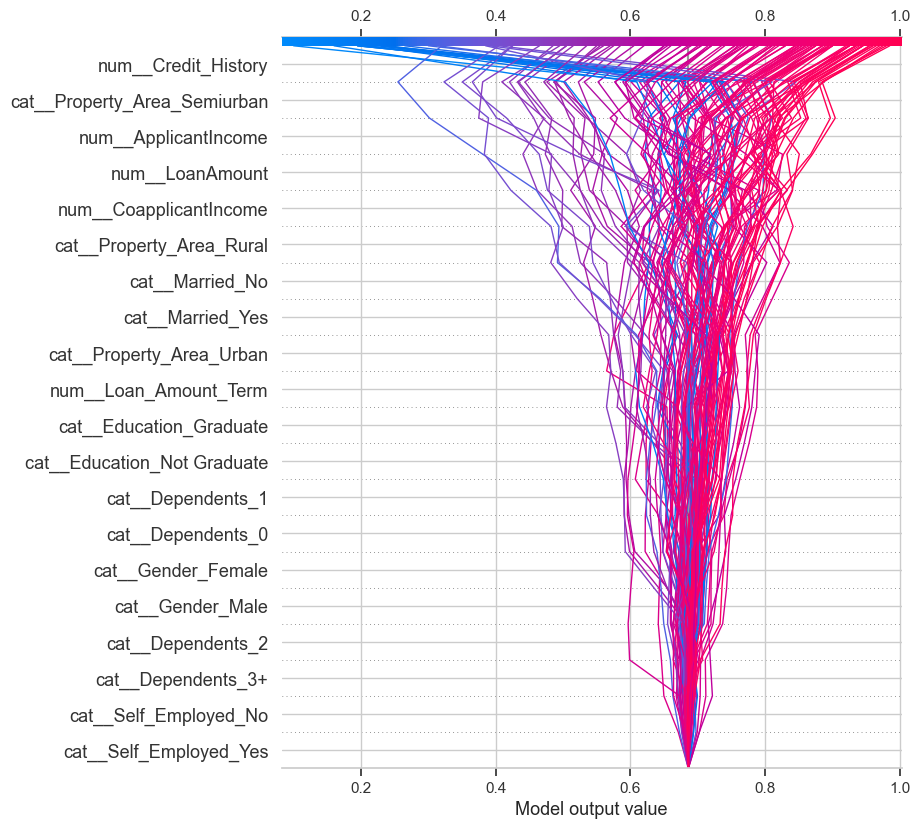

In [108]:
shap.decision_plot(
    shap_values.base_values[0, pos_idx],
    shap_values.values[:, :, pos_idx],
    feature_names=list(all_feature_names)
)

The SHAP decision plot reveals that credit history is the primary determinant of loan approval, producing the largest shifts in model output. Applicants with a positive credit history consistently move toward high approval probabilities, while those without are strongly rejected. Income-related features contribute moderately, refining predictions, whereas demographic variables such as gender and dependents have minimal influence. This indicates a financially grounded and interpretable decision process.

# Conclusion

This project applied machine learning to predict loan approval decisions using a dataset containing applicants’ financial and demographic information, with careful preprocessing to handle both numerical and categorical variables. Multiple models were evaluated, including Logistic Regression, Random Forest, and LightGBM, balancing predictive performance with interpretability. While ensemble models captured non-linear patterns, Logistic Regression remained competitive, indicating that loan decisions in the data are largely driven by a small number of strong predictors. Feature importance and SHAP analysis showed that credit history is the dominant factor influencing loan approval, followed by income and loan-related variables, while demographic attributes such as gender, marital status, and dependents have minimal impact. SHAP explanations further enabled transparent, instance-level interpretation of predictions, reinforcing trust in the model’s decisions. Overall, the results demonstrate that machine learning can effectively support loan approval processes in a way that is both accurate and interpretable, aligning well with real-world financial risk assessment and business requirements.